# Download de bibliotecas

In [5]:
!pip install tensorflow

In [8]:
!pip install numpy==1.23.5 pandas==2.2.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 57.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [9]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.9 MB/s eta 0:00:00


# Importando dados

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

In [17]:
# Imports para o Modelo de Série Temporal
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
# ... Outros imports (como a sua função make_stationary e plot_forecasts)

# >>> IMPORTS CHAVE PARA A REDE NEURAL (TensorFlow/Keras) <<<
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping # <--- ESTE É O IMPORT QUE ESTAVA FALTANDO!

In [6]:
import numpy as np # Geralmente já está importado, mas é bom garantir
from statsmodels.tsa.statespace.sarimax import SARIMAX # Necessário para SARIMAX
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [1]:
import pandas as pd
import os
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

caminho_dados = '/content/drive/Shareddrives/IC - Otimizacao computacional para inflacao/Dados'

# Listar os arquivos dentro da pasta "Dados"
arquivos_dados = os.listdir(caminho_dados)

print(arquivos_dados)


Mounted at /content/drive
['df_macro.csv', 'dados_USA', 'dados_macro.ipynb']


In [2]:
file_path = os.path.join(caminho_dados, 'df_macro.csv')

df = pd.read_csv(file_path, index_col='Date', parse_dates=True)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 154 entries, 2012-03-01 to 2024-12-01
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   IPCA                                   154 non-null    float64
 1   IPCA_Transportes                       154 non-null    float64
 2   IPCA Alimentação_bebidas               154 non-null    float64
 3   INPC_Habitação                         154 non-null    float64
 4   IPCA_Saúde_cuidados_pessoais           154 non-null    float64
 5   IPCA_Vestuário                         154 non-null    float64
 6   IPCA_Educação                          154 non-null    float64
 7   IPCA_Despesas_Pessoais                 154 non-null    float64
 8   USDBRL                                 154 non-null    float64
 9   Reservas Internacionais                154 non-null    int64  
 10  Desemprego                             154 non-null    

In [4]:
df.head()

,IPCA,IPCA_Transportes,IPCA Alimentação_bebidas,INPC_Habitação,IPCA_Saúde_cuidados_pessoais,IPCA_Vestuário,IPCA_Educação,IPCA_Despesas_Pessoais,USDBRL,Reservas Internacionais,...,IPC_BR,Produção_Derivados_Petróleo,Consumo_Gasolina,Consumo_Óleo_Combustível,Consumo_Energia_Comercial,Consumo_Energia_Residencial,Consumo_Energia_Total,Estoque_Empregos_Formais_Total,Estoque_Empregos_Formais_Agropecuária,Estoque_Empregos_Formais_Construção
Date,,,,,,,,,,,,,,,,,,,,,
2012-03-01,-0.08,0.16,0.25,0.43,0.38,-0.61,0.54,0.55,1.8221,365216,...,0.60,2169,537,59,7037,10271,38636,38754453,1470766,2910763
2012-04-01,0.55,0.10,0.51,0.73,0.96,0.98,0.04,2.23,1.8918,374272,...,0.52,2106,531,64,6856,9928,37996,39018063,1495548,2963001
2012-05-01,0.49,-0.58,0.73,0.82,0.66,0.89,-0.01,0.60,2.0223,372409,...,0.52,2136,527,61,6417,9532,36810,39213837,1549189,2989022
2012-06-01,-0.31,-1.18,0.68,0.24,0.38,0.39,0.06,0.47,2.0213,373910,...,0.11,2127,538,58,6282,9605,36528,39377064,1614204,3000347
2012-07-01,0.06,-0.03,0.91,0.51,0.36,0.04,0.12,0.91,2.0499,376154,...,0.22,2116,527,62,6033,9274,35917,39561060,1641519,3034369


# Funcoes auxiliares

In [21]:
import numpy as np
# ... outros imports ...
import matplotlib.pyplot as plt # Importação necessária para plotagem
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [22]:
import matplotlib.pyplot as plt

def plot_forecasts(y_true, y_pred, title="Previsão vs. Real"):
    """
    Plota o valor real (y_true) e o valor previsto (y_pred) no eixo temporal.

    y_true: Série Temporal ou array com os valores reais (IPCA).
    y_pred: Array com os valores previstos (hybrid_forecast).
    title: Título para o gráfico.
    """
    plt.figure(figsize=(12, 6))

    # Plotar o valor real
    plt.plot(y_true.index, y_true.values, label='Valor Real (IPCA)', color='blue', linewidth=2)

    # Plotar o valor previsto (híbrido)
    plt.plot(y_true.index, y_pred, label='Previsão Híbrida (ARIMAX + NN)', color='red', linestyle='--', linewidth=2)

    plt.title(title, fontsize=16)
    plt.xlabel('Data', fontsize=12)
    plt.ylabel('IPCA', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [10]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib

# Funções auxiliares

def make_stationary(df, max_diff=5):
    """Torna a série temporal estacionária através de diferenciação."""
    df_diff = df.copy()
    for i in range(1, max_diff + 1):
        stationary = True
        for column in df_diff.columns:
            if not check_stationarity(df_diff[[column]]):
                stationary = False
                df_diff[[column]] = df_diff[[column]].diff().fillna(method='ffill').fillna(method='bfill')
        if stationary:
            print(f"Série estacionária após {i-1} diferenciações.")
            return df_diff.dropna()
    raise ValueError("A série não se tornou estacionária após o número máximo de diferenciações.")

def check_stationarity(series, significance_level=0.05):
    """Verifica se a série é estacionária usando o teste ADF."""
    from statsmodels.tsa.stattools import adfuller
    result = adfuller(series.dropna())
    return result[1] < significance_level

def plot_forecasts(y_test, final_forecast, title='Previsão Dinâmica'):
    """Plota as previsões comparadas com os valores reais."""
    plt.figure(figsize=(15, 3))
    plt.plot(y_test.index, y_test, label='Valores Reais', color='blue')
    plt.plot(y_test.index, final_forecast, label='Previsão', color='orange')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# Hibrido (Arimax + RF)

In [11]:
import warnings
warnings.filterwarnings('ignore')

In [12]:
from sklearn.ensemble import RandomForestRegressor # Import RandomForestRegressor here
import matplotlib.pyplot as plt

In [13]:
random_state = 42

In [26]:
def executar_modelo_arimax_hibrido(df, exogenous_vars, tecnica_nome):
    # Tornar o DataFrame estacionário
    df_stationary = make_stationary(df[['IPCA'] + exogenous_vars])

    # Dividir em treino e teste
    train_size = int(len(df_stationary) * 0.8)
    train, test = df_stationary.iloc[:train_size], df_stationary.iloc[train_size:]

    # Variável dependente e exógenas
    y_train = train['IPCA']
    y_test = test['IPCA']
    X_train = train[exogenous_vars]
    X_test = test[exogenous_vars]

    # Ajustar modelo ARIMAX com auto_arima (Sazonalidade adicionada como sugestão)
    arimax_model = auto_arima(y_train, exogenous=X_train, seasonal=True, m=12, trace=False,
                                error_action='ignore', suppress_warnings=True)
    arimax_order = arimax_model.order

    # --- 1. PREVISÃO E RESÍDUOS NO CONJUNTO DE TREINO (PARA TREINAR A NN) ---
    # Previsão in-sample para calcular os resíduos de TREINAMENTO
    # A previsão 'in-sample' é feita diretamente pelo objeto arimax_model ajustado
    arimax_train_forecast = arimax_model.predict(n_periods=len(y_train), exogenous=X_train)
    residuals_train = y_train.values - arimax_train_forecast

    # Preparar dados para a Rede Neural (Conjunto de TREINO)
    X_nn_train = X_train.values
    y_nn_train = residuals_train
    input_dim = X_nn_train.shape[1]

    # 1. Definir o modelo de Rede Neural (MLP)
    nn_model = Sequential()
    nn_model.add(Dense(32, activation='relu', input_shape=(input_dim,)))
    nn_model.add(Dense(1, activation='linear'))

    # 2. Compilar o modelo
    nn_model.compile(optimizer='adam', loss='mean_squared_error')

    # 3. Definir Early Stopping (monitora o erro no treino, usando validação interna)
    early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min')

    # 4. Treinar o modelo nos resíduos de TREINAMENTO
    nn_model.fit(X_nn_train, y_nn_train,
                 epochs=200,
                 batch_size=16,
                 verbose=0,
                 validation_split=0.2,
                 callbacks=[early_stop]
                )

    # --- 2. PREVISÃO DINÂMICA NO CONJUNTO DE TESTE (ARIMAX) ---
    dynamic_arimax_forecast = []
    history_y = list(y_train)
    history_X = list(X_train.values)

    for t in range(len(y_test)):
        # Reajustar o modelo em cada passo (abordagem dinâmica)
        model = SARIMAX(history_y, exog=np.array(history_X), order=arimax_order)
        fitted_model = model.fit(disp=False)
        next_x = X_test.iloc[t].values.reshape(1, -1)
        forecast = fitted_model.forecast(steps=1, exog=next_x)
        dynamic_arimax_forecast.append(forecast[0])

        # Atualizar histórico
        history_y.append(y_test.iloc[t])
        history_X.append(X_test.iloc[t].values)

    # --- 3. PREVISÃO DE RESÍDUOS NO CONJUNTO DE TESTE (NN) ---

    # 5. Previsão dos resíduos com Rede Neural (usa features de TESTE)
    X_nn_test = X_test.values
    predicted_residuals_nn_raw = nn_model.predict(X_nn_test, verbose=0)
    predicted_residuals_nn = predicted_residuals_nn_raw.flatten()

    # Previsão híbrida: ARIMAX + NN
    hybrid_forecast = np.array(dynamic_arimax_forecast) + predicted_residuals_nn

    # Métricas de desempenho (Calculadas sobre o forecast HÍBRIDO)
    mse = mean_squared_error(y_test, hybrid_forecast)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, hybrid_forecast)
    mape = np.mean(np.abs((y_test - hybrid_forecast) / y_test))

    print(f'MAE: {mae:.6f}')
    print(f'MSE: {mse:.6f}')
    print(f'RMSE: {rmse:.6f}')
    print(f'MAPE: {mape:.6f}')

    # Plotar resultados (Realiza o plot do previsto x real)
    plot_forecasts(y_test, hybrid_forecast, title=f'{tecnica_nome} (ARIMAX + Rede Neural)')

# Implementacao

5 features - GA

Série estacionária após 1 diferenciações.
Epoch 11: early stopping


MAE: 0.403837
MSE: 0.231833
RMSE: 0.481490
MAPE: 2.641128


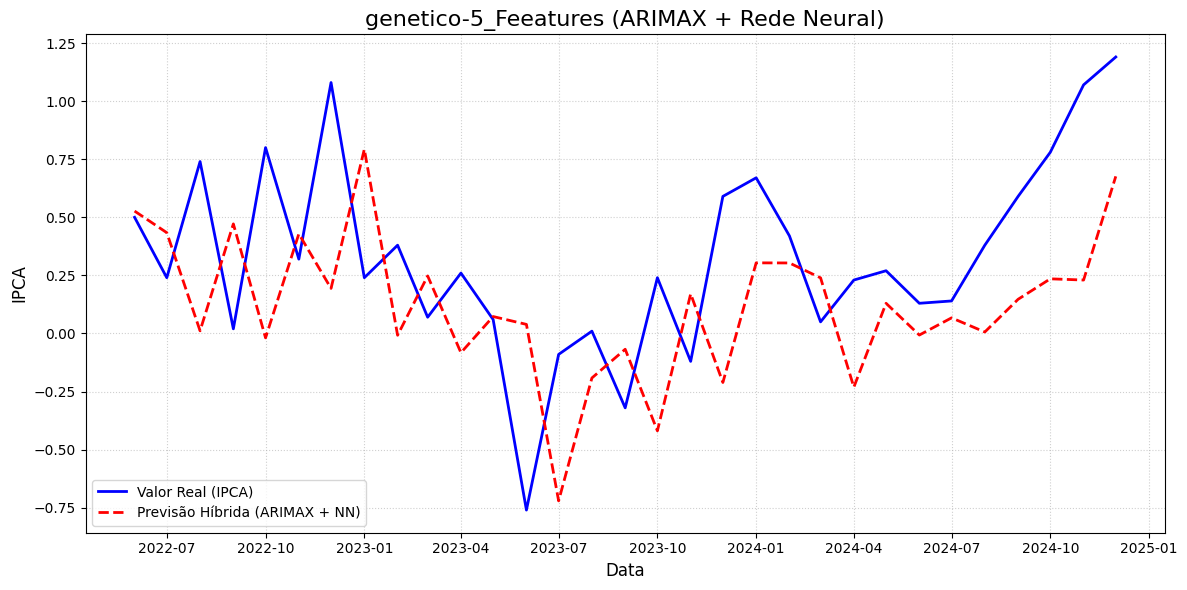

In [29]:
exogenous_vars= ['INPC_Habitação', 'IPCA_Despesas_Pessoais', 'USDBRL']
executar_modelo_arimax_hibrido(df,exogenous_vars,'genetico-5_Feeatures')